Ladda in paketen. Notera att vi kommer behöva digammafunktionen $\Psi(\alpha) = \Gamma'(\alpha)/\Gamma(\alpha)$ från `scipy.special`.

In [1]:
import numpy as np
from scipy import stats
from scipy.special import digamma
import matplotlib.pyplot as plt

Sätt det sanna värdet på parametern $\alpha$ och generera ett stickprov av storlek $n = 987$.

In [2]:
n = 987
alpha_true = 3.9

xs = stats.gamma.rvs(a=alpha_true, size=n)

Undersök histogrammet för stickprovet. Borde approximera täthetsfunktionen $f_X(x \mid \alpha)$.

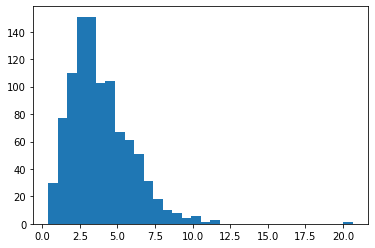

In [3]:
plt.hist(xs, bins=32)
plt.show()

Genomför gradientsökningen. Vi har följande täthetsfunktion
$$
    f_X(x \mid \alpha) = \frac{1}{\Gamma(\alpha)} x^{\alpha-1} e^{-x}
$$
vilket ger
$$
    \begin{split}
        \frac{1}{n}\ell(\alpha \mid \mathbf{x}) &= \frac{1}{n}\sum_{i=1}^n \log f_X(x_i \mid \alpha) \\
        &= \frac{1}{n}\sum_{i=1}^n -\log \Gamma(\alpha) + (\alpha-1) \log x_i - x_i \\
        &= -\log \Gamma(\alpha) + \frac{1}{n} \sum_{i=1}^n (\alpha-1) \log x_i - x_i.
    \end{split}
$$
Vi deriverar och får då
$$
        \frac{1}{n} \frac{d\ell}{d\alpha}(\alpha \mid \mathbf{x}) = -\frac{\Gamma'(\alpha)}{\Gamma(\alpha)} + \frac{1}{n} \sum_{i=1}^n \log x_i.
$$

Notera att vi här använder den *normaliserade log-likelihoodfunktionen* $\frac{1}{n} \ell(\alpha \mid x)$. Anledningen är att funktionens storlek, och dess gradient, annars varierar med stickprovsstorleken, vilket gör att, t.ex. steglängden kan behöva varieras när stickprovet ändras i storlek. 

In [4]:
max_iter = 100                 # Antalet iterationer
step_size = 1.                 # Steglängden (γ i anteckningarna)

# Skapa vektor för att spara de successiva skattningarna av α.
alpha_ests = []

# Lägg in vår initiala gissning för α.
alpha_ests.append(1.)

for _ in range(max_iter):
    # Ta fram skattningen för föregående iteration.
    alpha_est = alpha_ests[-1]
    
    # Beräkna gradienten (här bara derivatan).
    alpha_grad = -digamma(alpha_est) + np.mean(np.log(xs))
    
    # Stega skattningen i gradientens riktning med vår steglängd.
    alpha_est = alpha_est + step_size * alpha_grad
    
    # Spara nya skattningen.
    alpha_ests.append(alpha_est)

Se hur skattningen konvergerar.

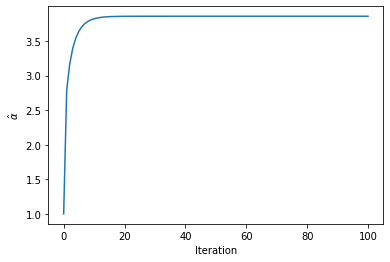

In [5]:
plt.plot(alpha_ests)
plt.xlabel("Iteration")
plt.ylabel(r"$\hat \alpha$")
plt.show()

Jämför slutgiltiga skattningen med sanna värdet.

In [6]:
print(f"α = {alpha_true}, α-hatt = {alpha_ests[-1]}")

α = 3.9, α-hatt = 3.856850977497648


Nu skattar vi både $\alpha$ och $\lambda$.

Som innan genererar vi först lite data. Notera att SciPy parametriserar gammafördelningen med hjälp av skala (`scale`) inte intensitet $\lambda$ som vi gör i kursen.

In [7]:
n = 987
alpha_true = 3.9
lambda_true = 1.6

xs = stats.gamma.rvs(a=alpha_true, scale=1 / lambda_true, size=n)

Denna gång behöver vi hela gradienten, dvs. partialderivatorna med avseende på både $\alpha$ och $\lambda$. Täthetsfunktionen ges av
$$
    f_X(x \mid \alpha) = \frac{\lambda^\alpha}{\Gamma(\alpha)} x^{\alpha-1} e^{-\lambda x}
$$
Vi har då den normaliserade log-likelihoodfunktionen
$$
    \begin{split}
        \frac{1}{n}\ell(\alpha, \lambda \mid \mathbf{x}) &= \frac{1}{n}\sum_{i=1}^n \log f_X(x_i \mid \alpha, \lambda) \\
        &= \frac{1}{n}\sum_{i=1}^n \alpha \log \lambda -\log \Gamma(\alpha) + (\alpha-1) \log x_i - \lambda x_i \\
        &= \alpha \log \lambda - \log \Gamma(\alpha) + \frac{1}{n} \sum_{i=1}^n (\alpha-1) \log x_i - \lambda x_i.
    \end{split}
$$
Vi får då
$$
    \begin{split}
        \frac{1}{n} \frac{\partial \ell}{\partial \alpha} \ell(\alpha, \lambda \mid \mathbf{x}) &= \log \lambda - \frac{\Gamma'(\alpha)}{\Gamma(\alpha)} + \frac{1}{n} \sum_{i=1}^n \log x_i \\
        \frac{1}{n} \frac{\partial \ell}{\partial \lambda} \ell(\alpha, \lambda \mid \mathbf{x}) &= \frac{\alpha}{\lambda} - \frac{1}{n} \sum_{i=1} x_i.
    \end{split}
$$

In [8]:
max_iter = 10000
step_size = 0.1

alpha_ests = []
lambda_ests = []

alpha_ests.append(1.)
lambda_ests.append(1.)

for _ in range(max_iter):
    alpha_est = alpha_ests[-1]
    lambda_est = lambda_ests[-1]
    
    alpha_grad = np.log(lambda_est) - digamma(alpha_est) + np.mean(np.log(xs))
    lambda_grad = alpha_est / lambda_est - np.mean(xs)
    
    alpha_est += step_size * alpha_grad
    lambda_est += step_size * lambda_grad
    
    alpha_ests.append(alpha_est)
    lambda_ests.append(lambda_est)

Undersök konvergensen i både $\alpha$ och $\lambda$.

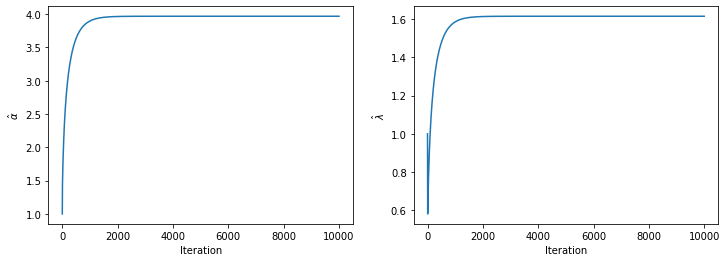

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(alpha_ests)
plt.xlabel("Iteration")
plt.ylabel(r"$\hat \alpha$")
plt.subplot(1, 2, 2)
plt.plot(lambda_ests)
plt.xlabel("Iteration")
plt.ylabel(r"$\hat \lambda$")
plt.show()

Vi kan också plotta de successiva skattningarna samtidigt i både $\alpha$ och $\lambda$. Notera att de första stegen är ganska stora, men att algoritmen sedan saktar ned i samband med att den närmar sig maximumet.

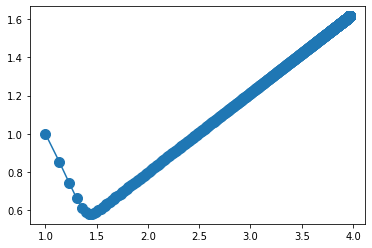

In [10]:
plt.plot(alpha_ests, lambda_ests, '.-', markersize=20)
plt.show()

Jämför skattningarna med sanna parametervärdena.

In [11]:
print(f"α = {alpha_true}, α-hatt = {alpha_ests[-1]}")
print(f"α = {lambda_true}, α-hatt = {lambda_ests[-1]}")

α = 3.9, α-hatt = 3.9688141411102906
α = 1.6, α-hatt = 1.6159861769042705
